In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
sns.set_palette('deep')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.titleweight': 'bold',
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'legend.fontsize': 11,
    'grid.alpha': 0.25
})

In [5]:
data_path = '../data/processed/fuel_prices_Indonesia.csv'
# Wenn vorhanden, können Sie hier Assignment_Data.csv verwenden:
# data_path = '../data/processed/Assignment_Data.csv'

df = pd.read_csv(data_path, parse_dates=['date'])
df = df.set_index('date').sort_index()

print('Datensatz:', data_path)
print('Zeilen, Spalten:', df.shape)
print('Spalten:', df.columns.tolist())
df.head()

Datensatz: ../data/processed/fuel_prices_Indonesia.csv
Zeilen, Spalten: (327, 9)
Spalten: ['country', 'region', 'income_level', 'subsidy_level', 'petrol_usd_liter', 'diesel_usd_liter', 'lpg_usd_liter', 'brent_crude_usd', 'tax_percentage']


,country,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
date,,,,,,,,,
2020-01-06,Indonesia,Asia,Middle,High,0.540,0.520,0.431,65.75,28.6
2020-01-13,Indonesia,Asia,Middle,High,0.555,0.530,0.432,65.54,3.0
2020-01-20,Indonesia,Asia,Middle,High,0.542,0.518,0.407,66.51,13.2
2020-01-27,Indonesia,Asia,Middle,High,0.551,0.527,0.411,68.79,25.3
2020-02-03,Indonesia,Asia,Middle,High,0.549,0.484,0.436,68.44,9.6


Beschreibung der Zeitreihe y:
count    327.000000
mean       0.882113
std        0.156981
min        0.413000
25%        0.831000
50%        0.931000
75%        0.988000
max        1.106000
Name: petrol_usd_liter, dtype: float64


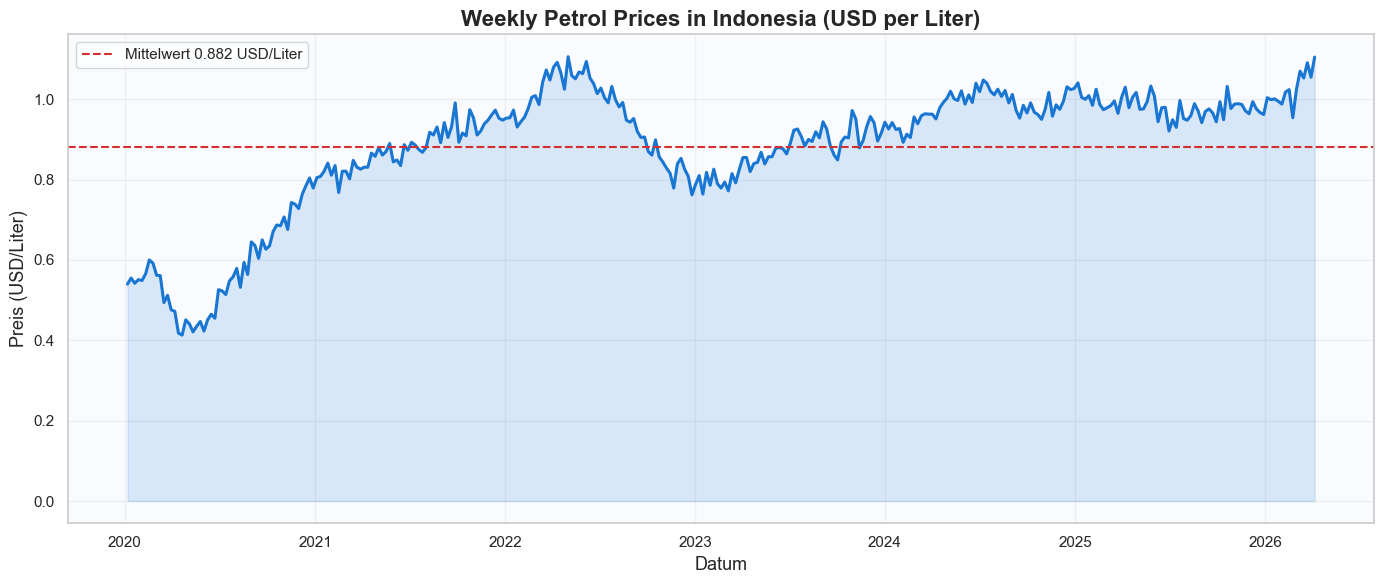

In [6]:
y = df['petrol_usd_liter'].copy()
y = y.asfreq('W-MON')

print('Beschreibung der Zeitreihe y:')
print(y.describe())

fig, ax = plt.subplots()
sns.lineplot(x=y.index, y=y.values, ax=ax, color='#1976D2', linewidth=2.2)
ax.fill_between(y.index, y.values, alpha=0.15, color='#1976D2')
ax.axhline(y.mean(), color='#D32F2F', linestyle='--', linewidth=1.5,
           label=f'Mittelwert {y.mean():.3f} USD/Liter')
ax.set_title('Weekly Petrol Prices in Indonesia (USD per Liter)')
ax.set_xlabel('Datum')
ax.set_ylabel('Preis (USD/Liter)')
ax.legend()
ax.set_facecolor('#f9fbff')
plt.tight_layout()
plt.show()

In [7]:
from statsmodels.tsa.stattools import adfuller, kpss


def stationarity_tests(series, title):
    print(f'--- {title} ---')
    adf = adfuller(series, autolag='AIC')
    print(f'ADF: stat={adf[0]:.4f}, p-value={adf[1]:.4f}, usedlag={adf[2]}')
    print('    Ergebnis: Stationär' if adf[1] < 0.05 else '    Ergebnis: Nicht stationär')
    kpss_res = kpss(series, regression='c', nlags='auto')
    print(f'KPSS: stat={kpss_res[0]:.4f}, p-value={kpss_res[1]:.4f}')
    print('    Ergebnis: H0 nicht verworfen → Stationär' if kpss_res[1] > 0.05 else '    Ergebnis: H0 verworfen → Nicht stationär')
    print()

stationarity_tests(y, 'Originalreihe y')

--- Originalreihe y ---
ADF: stat=-1.8908, p-value=0.3364, usedlag=9
    Ergebnis: Nicht stationär
KPSS: stat=1.5154, p-value=0.0100
    Ergebnis: H0 verworfen → Nicht stationär



--- Erste Differenz Δy ---
ADF: stat=-4.0580, p-value=0.0011, usedlag=8
    Ergebnis: Stationär
KPSS: stat=0.1239, p-value=0.1000
    Ergebnis: H0 nicht verworfen → Stationär



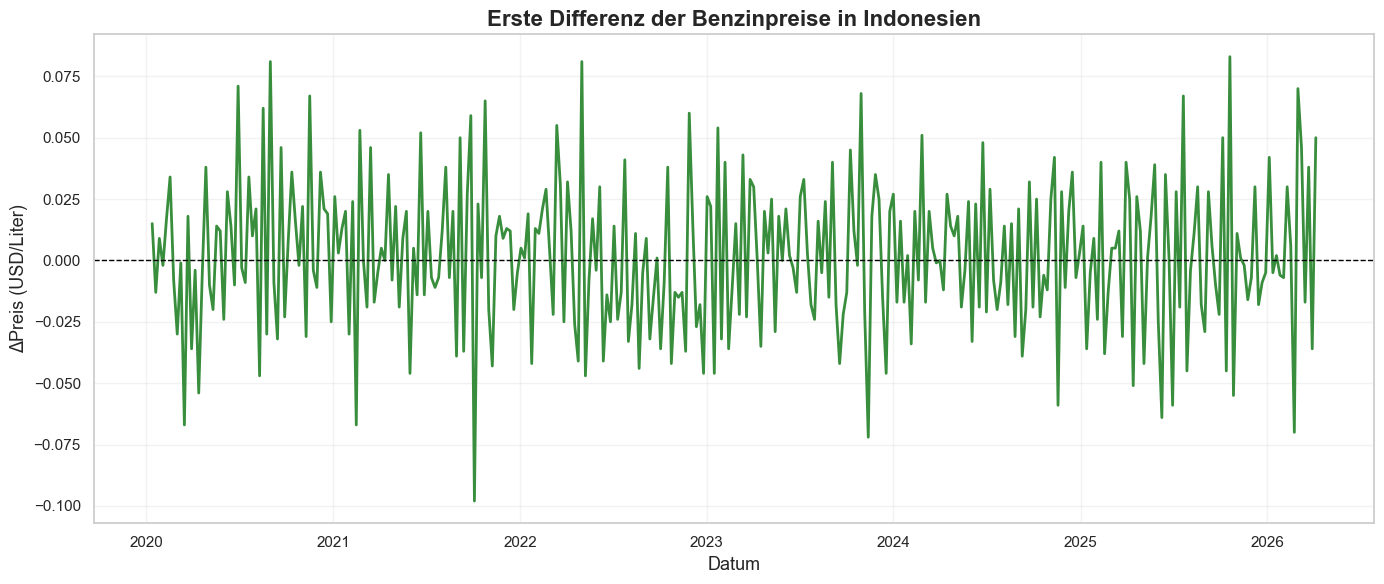

In [8]:
y_diff = y.diff().dropna()
stationarity_tests(y_diff, 'Erste Differenz Δy')

fig, ax = plt.subplots()
sns.lineplot(x=y_diff.index, y=y_diff.values, ax=ax, color='#388E3C', linewidth=2)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Erste Differenz der Benzinpreise in Indonesien')
ax.set_xlabel('Datum')
ax.set_ylabel('ΔPreis (USD/Liter)')
plt.tight_layout()
plt.show()

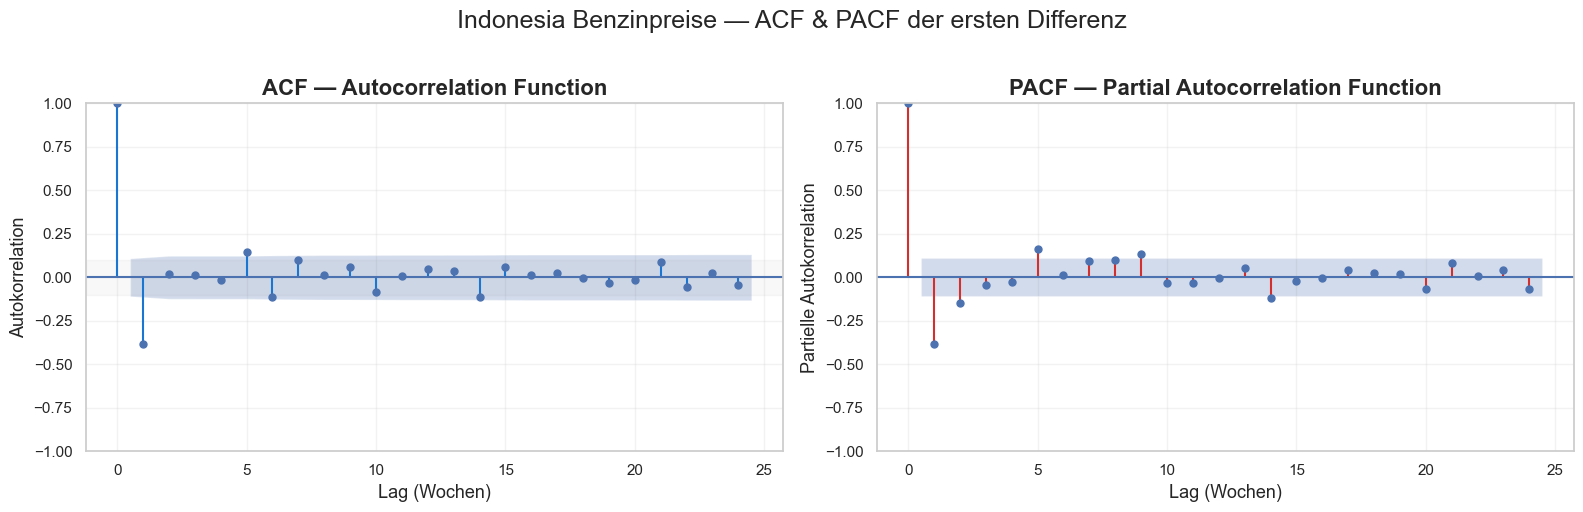

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(y_diff, lags=24, ax=axes[0], title='ACF — Autocorrelation Function', alpha=0.05,
         vlines_kwargs={'colors': '#1976D2'})
axes[0].axhspan(-0.1, 0.1, alpha=0.05, color='grey')
axes[0].set_xlabel('Lag (Wochen)')
axes[0].set_ylabel('Autokorrelation')

plot_pacf(y_diff, lags=24, ax=axes[1], title='PACF — Partial Autocorrelation Function', method='ywm', alpha=0.05,
          vlines_kwargs={'colors': '#D32F2F'})
axes[1].set_xlabel('Lag (Wochen)')
axes[1].set_ylabel('Partielle Autokorrelation')

fig.suptitle('Indonesia Benzinpreise — ACF & PACF der ersten Differenz', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [10]:
from statsmodels.tsa.arima.model import ARIMA

candidates = []
for p in range(0, 4):
    for q in range(0, 4):
        try:
            model = ARIMA(y, order=(p, 1, q)).fit()
            candidates.append({
                'p': p,
                'd': 1,
                'q': q,
                'Model': f'ARIMA({p},1,{q})',
                'AIC': model.aic,
                'BIC': model.bic,
                'HQIC': model.hqic
            })
        except Exception:
            continue

results_df = pd.DataFrame(candidates).sort_values('AIC').reset_index(drop=True)
results_df['AIC'] = results_df['AIC'].round(2)
results_df['BIC'] = results_df['BIC'].round(2)
results_df['HQIC'] = results_df['HQIC'].round(2)
results_df.head(10)

,p,d,q,Model,AIC,BIC,HQIC
0,2,1,3,"ARIMA(2,1,3)",-1425.40,-1402.68,-1416.33
1,3,1,3,"ARIMA(3,1,3)",-1423.07,-1396.56,-1412.49
2,2,1,2,"ARIMA(2,1,2)",-1419.30,-1400.37,-1411.75
3,1,1,2,"ARIMA(1,1,2)",-1419.27,-1404.13,-1413.23
4,1,1,3,"ARIMA(1,1,3)",-1417.23,-1398.30,-1409.67
5,0,1,1,"ARIMA(0,1,1)",-1410.72,-1403.15,-1407.70
6,0,1,2,"ARIMA(0,1,2)",-1410.19,-1398.83,-1405.65
7,2,1,0,"ARIMA(2,1,0)",-1410.02,-1398.66,-1405.49
8,1,1,1,"ARIMA(1,1,1)",-1409.89,-1398.53,-1405.35
9,0,1,3,"ARIMA(0,1,3)",-1409.81,-1394.67,-1403.77


In [11]:
styled = results_df.style \
    .background_gradient(subset=['AIC', 'BIC', 'HQIC'], cmap='RdYlGn_r') \
    .highlight_min(subset=['AIC'], color='#81C784') \
    .highlight_min(subset=['BIC'], color='#64B5F6') \
    .set_caption('ARIMA-Modellvergleich — Beste Kandidaten für Indonesien') \
    .format({'AIC': '{:.2f}', 'BIC': '{:.2f}', 'HQIC': '{:.2f}'})

styled

,p,d,q,Model,AIC,BIC,HQIC
0,2,1,3,"ARIMA(2,1,3)",-1425.40,-1402.68,-1416.33
1,3,1,3,"ARIMA(3,1,3)",-1423.07,-1396.56,-1412.49
2,2,1,2,"ARIMA(2,1,2)",-1419.30,-1400.37,-1411.75
3,1,1,2,"ARIMA(1,1,2)",-1419.27,-1404.13,-1413.23
4,1,1,3,"ARIMA(1,1,3)",-1417.23,-1398.30,-1409.67
5,0,1,1,"ARIMA(0,1,1)",-1410.72,-1403.15,-1407.70
6,0,1,2,"ARIMA(0,1,2)",-1410.19,-1398.83,-1405.65
7,2,1,0,"ARIMA(2,1,0)",-1410.02,-1398.66,-1405.49
8,1,1,1,"ARIMA(1,1,1)",-1409.89,-1398.53,-1405.35
9,0,1,3,"ARIMA(0,1,3)",-1409.81,-1394.67,-1403.77


In [12]:
from statsmodels.stats.diagnostic import acorr_ljungbox
import statsmodels.api as sm

best_row = results_df.loc[results_df['AIC'].idxmin()]
best_order = (int(best_row['p']), int(best_row['d']), int(best_row['q']))
print('Bestes Modell nach AIC:', best_row['Model'])

model = ARIMA(y, order=best_order).fit()
residuals = model.resid

print(model.summary())

coeff_table = pd.DataFrame({
    'Parameter': model.params,
    'Std.Err.': model.bse,
    't-Wert': model.tvalues,
    'p-Wert': model.pvalues
})
coeff_table = coeff_table.round(4)
coeff_table

Bestes Modell nach AIC: ARIMA(2,1,3)
                               SARIMAX Results                                
Dep. Variable:       petrol_usd_liter   No. Observations:                  327
Model:                 ARIMA(2, 1, 3)   Log Likelihood                 718.701
Date:                Thu, 14 May 2026   AIC                          -1425.402
Time:                        13:43:33   BIC                          -1402.680
Sample:                    01-06-2020   HQIC                         -1416.335
                         - 04-06-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0734      0.090     -0.813      0.416      -0.250       0.104
ar.L2          0.7796      0.091      8.568      0.000       0.601       0.958
ma.L1         -

,Parameter,Std.Err.,t-Wert,p-Wert
ar.L1,-0.0734,0.0903,-0.8126,0.4164
ar.L2,0.7796,0.0910,8.5677,0.0000
ma.L1,-0.3805,0.0839,-4.5364,0.0000
ma.L2,-0.8487,0.0631,-13.4474,0.0000
ma.L3,0.5171,0.0507,10.2040,0.0000
sigma2,0.0007,0.0001,13.0307,0.0000


Residual-Statistik:
count    327.0000
mean       0.0035
std        0.0399
min       -0.0804
25%       -0.0167
50%        0.0013
75%        0.0204
max        0.5400
dtype: float64


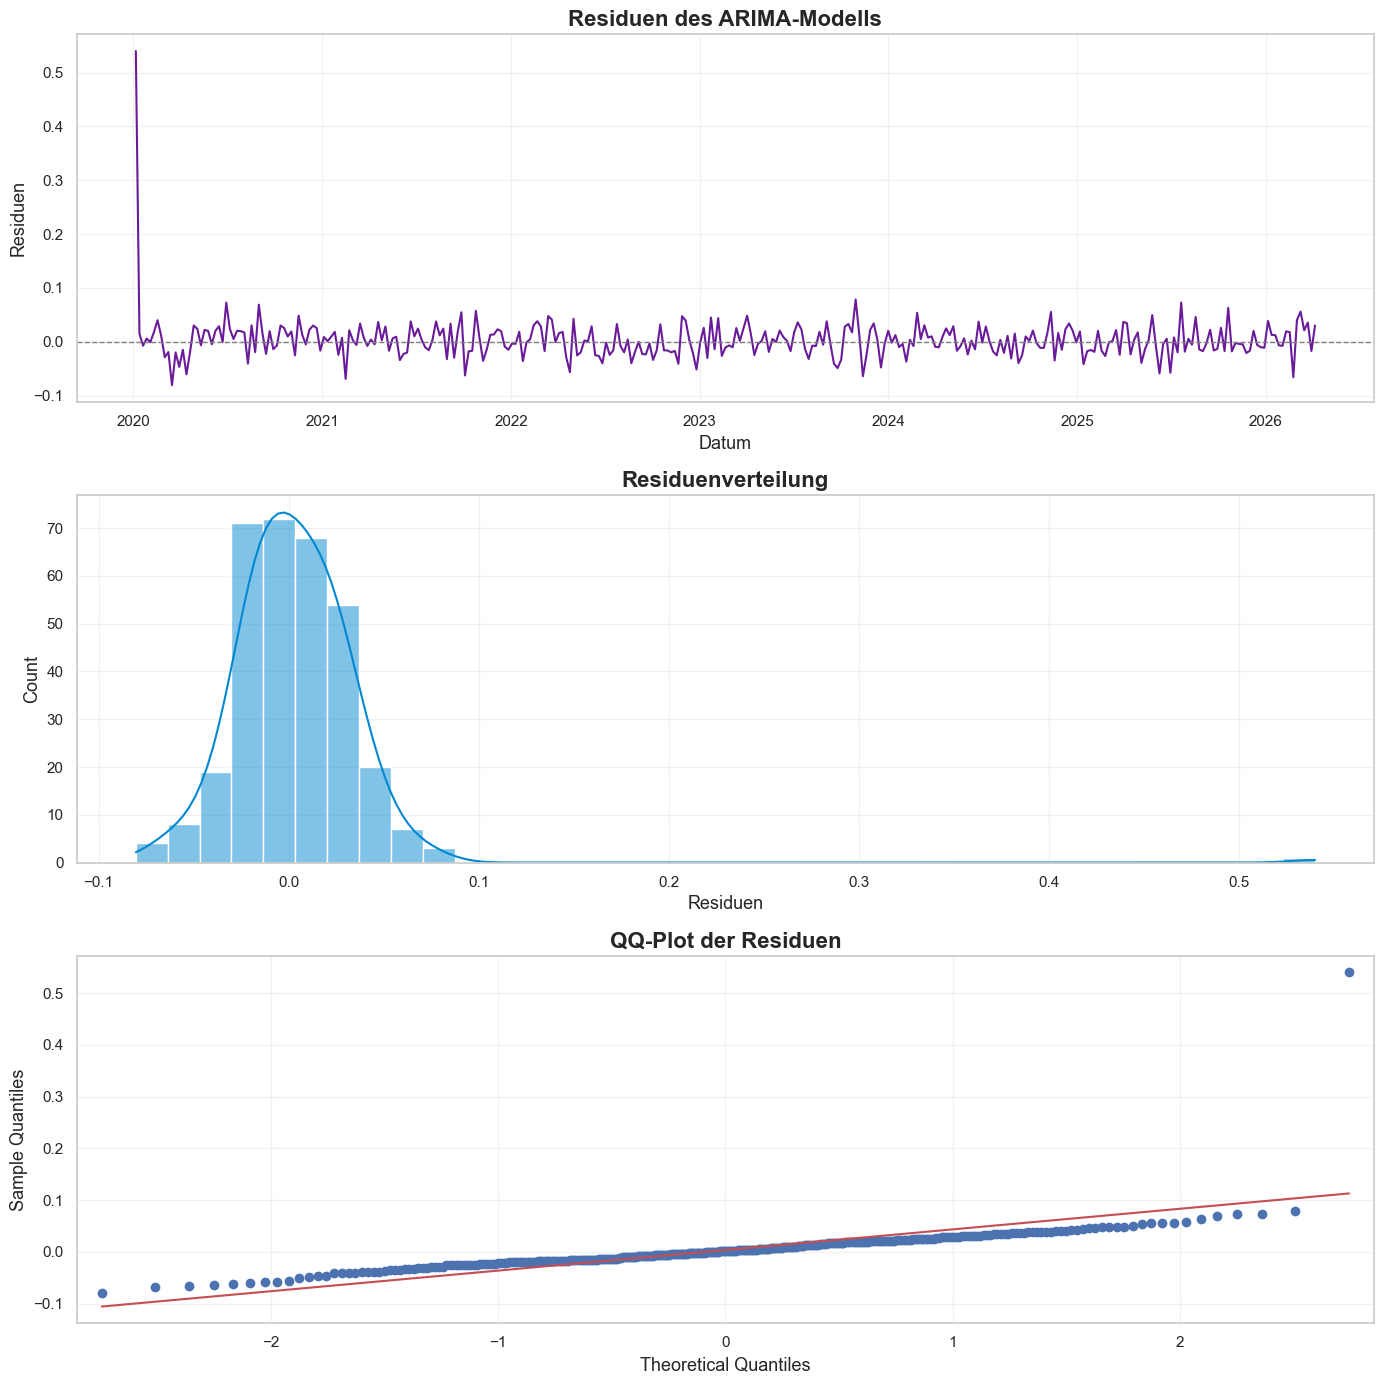

Ljung-Box-Test:
      lb_stat  lb_pvalue
10   6.499774   0.771674
20  13.447554   0.857367

Residuen sind unkorreliert


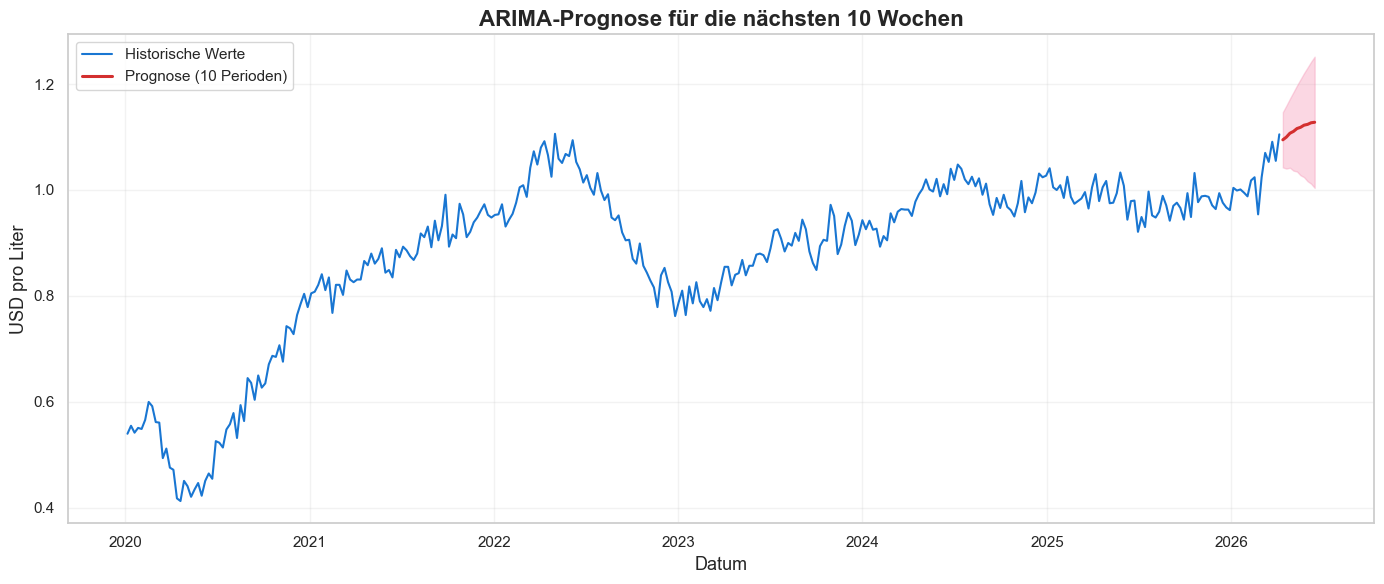

petrol_usd_liter,mean,mean_ci_lower,mean_ci_upper
2026-04-13,1.0947,1.0426,1.1468
2026-04-20,1.0998,1.0404,1.1592
2026-04-27,1.1071,1.0420,1.1722
2026-05-04,1.1105,1.0365,1.1845
2026-05-11,1.1160,1.0349,1.1970
2026-05-18,1.1182,1.0278,1.2087
2026-05-25,1.1223,1.0242,1.2204
2026-06-01,1.1238,1.0165,1.2310
2026-06-08,1.1269,1.0119,1.2418
2026-06-15,1.1278,1.0040,1.2515


In [13]:
# Residuen und Modellvalidierung

print('Residual-Statistik:')
print(residuals.describe().round(4))

fig, axes = plt.subplots(3, 1, figsize=(14, 14))

sns.lineplot(x=residuals.index, y=residuals.values, ax=axes[0], color='#6A1B9A')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0].set_title('Residuen des ARIMA-Modells')
axes[0].set_xlabel('Datum')
axes[0].set_ylabel('Residuen')

sns.histplot(residuals, kde=True, ax=axes[1], color='#0288D1', edgecolor='white')
axes[1].set_title('Residuenverteilung')
axes[1].set_xlabel('Residuen')

sm.qqplot(residuals, line='s', ax=axes[2], color='#D32F2F')
axes[2].set_title('QQ-Plot der Residuen')

plt.tight_layout()
plt.show()

lb = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
print('Ljung-Box-Test:')
print(lb)
print('\nResiduen sind unkorreliert' if lb['lb_pvalue'].iloc[-1] > 0.05 else '\nResiduen weisen Autokorrelation auf')

# Prognose für die nächsten 10 Perioden
forecast_steps = 10
forecast = model.get_forecast(steps=forecast_steps)
forecast_df = forecast.summary_frame(alpha=0.05)

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(x=y.index, y=y.values, ax=ax, label='Historische Werte', color='#1976D2')
ax.plot(forecast_df.index, forecast_df['mean'], color='#D32F2F', linewidth=2.2, label='Prognose (10 Perioden)')
ax.fill_between(forecast_df.index, forecast_df['mean_ci_lower'], forecast_df['mean_ci_upper'], color='#F48FB1', alpha=0.35)
ax.set_title('ARIMA-Prognose für die nächsten 10 Wochen')
ax.set_xlabel('Datum')
ax.set_ylabel('USD pro Liter')
ax.legend()
plt.tight_layout()
plt.show()

forecast_df[['mean', 'mean_ci_lower', 'mean_ci_upper']].round(4)